# Task 3: Sentiment Analysis & Correlation with Stock Returns
## Nova Financial Solutions | NLP & Statistical Analysis

In [1]:
import os
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import yfinance as yf
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import warnings
warnings.filterwarnings('ignore')

os.chdir(r'C:\Users\bamla\OneDrive\Desktop\news-sentiment-analysis')
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')
print("✓ Setup complete")

✓ Setup complete


In [2]:
# Load news
news = pd.read_csv('data/raw/raw_analyst_ratings.csv')
news['date'] = pd.to_datetime(news['date'], utc=True, errors='coerce')
news = news.dropna(subset=['date', 'headline'])
news['date_only'] = news['date'].dt.date

# VADER sentiment
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    try:
        return analyzer.polarity_scores(str(text))['compound']
    except:
        return 0.0

def get_label(score):
    if score >= 0.05: return 'Positive'
    elif score <= -0.05: return 'Negative'
    else: return 'Neutral'

news['sentiment_score'] = news['headline'].apply(get_sentiment)
news['sentiment_label'] = news['sentiment_score'].apply(get_label)

print(f"✓ News loaded: {len(news):,} articles")
print(f"Date range: {news['date_only'].min()} to {news['date_only'].max()}")
print(f"\nSentiment distribution:")
print(news['sentiment_label'].value_counts())

✓ News loaded: 55,987 articles
Date range: 2011-04-28 to 2020-06-11

Sentiment distribution:
sentiment_label
Neutral     26364
Positive    16423
Negative    13200
Name: count, dtype: int64


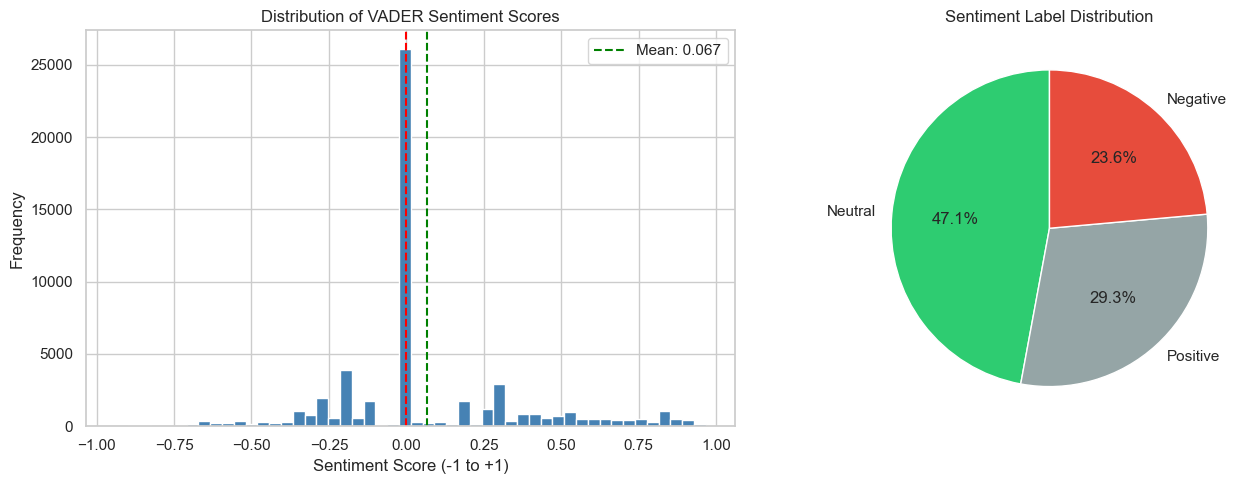

✓ Sentiment distribution plot saved


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(news['sentiment_score'], bins=50,
             color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].axvline(news['sentiment_score'].mean(), color='green',
                linestyle='--', linewidth=1.5,
                label=f"Mean: {news['sentiment_score'].mean():.3f}")
axes[0].set_title('Distribution of VADER Sentiment Scores')
axes[0].set_xlabel('Sentiment Score (-1 to +1)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

colors = ['#2ecc71', '#95a5a6', '#e74c3c']
counts = news['sentiment_label'].value_counts()
axes[1].pie(counts.values, labels=counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Sentiment Label Distribution')

plt.tight_layout()
plt.savefig('notebooks/sentiment_distribution.png', dpi=150)
plt.show()
print("✓ Sentiment distribution plot saved")

In [4]:
# Aggregate ALL articles by date
market_sentiment = news.groupby('date_only').agg(
    avg_sentiment=('sentiment_score', 'mean'),
    article_count=('headline', 'count')
).reset_index()

# Convert date_only to proper date objects
market_sentiment['date_only'] = pd.to_datetime(
    market_sentiment['date_only']
).dt.date

print(f"✓ Daily sentiment records: {len(market_sentiment)}")
print(f"\nSentiment stats:")
print(market_sentiment['avg_sentiment'].describe().round(3))

✓ Daily sentiment records: 2502

Sentiment stats:
count    2502.000
mean        0.077
std         0.158
min        -0.802
25%         0.000
50%         0.064
75%         0.151
max         0.791
Name: avg_sentiment, dtype: float64


In [5]:
# Download SPY as flat dataframe
spy_raw = yf.download('SPY', start='2011-01-01',
                       end='2020-12-31', auto_adjust=False)

# Flatten multi-level columns
spy_raw.columns = ['_'.join(col).strip() if isinstance(col, tuple) 
                   else col for col in spy_raw.columns]

# Get adj close column
adj_col = [c for c in spy_raw.columns if 'Adj' in c][0]
spy = spy_raw[[adj_col]].copy()
spy.columns = ['Adj_Close']
spy['daily_return'] = spy['Adj_Close'].pct_change() * 100
spy = spy.dropna().reset_index()
spy.columns = [str(c) for c in spy.columns]
spy['date_only'] = pd.to_datetime(spy['Date']).dt.date

print(f"✓ SPY data: {len(spy)} trading days")
print(f"Date range: {spy['date_only'].min()} to {spy['date_only'].max()}")
spy[['date_only', 'Adj_Close', 'daily_return']].head()

[*********************100%***********************]  1 of 1 completed

✓ SPY data: 2515 trading days
Date range: 2011-01-04 to 2020-12-30


,date_only,Adj_Close,daily_return
0,2011-01-04,96.874763,-0.055090
1,2011-01-05,97.378288,0.519769
2,2011-01-06,97.187576,-0.195847
3,2011-01-07,96.996826,-0.196270
4,2011-01-10,96.874763,-0.125842


In [6]:
# Get SPY trading days
spy_trading_days = set(spy['date_only'])

def align_to_trading_day(d):
    for i in range(5):
        if d in spy_trading_days:
            return d
        d += datetime.timedelta(days=1)
    return None

# Align news dates to trading days
market_sentiment['aligned_date'] = market_sentiment['date_only'].apply(
    align_to_trading_day
)
market_sentiment = market_sentiment.dropna(subset=['aligned_date'])

# Merge
spy_lookup = spy[['date_only', 'daily_return']].copy()

merged_spy = pd.merge(
    market_sentiment,
    spy_lookup,
    left_on='aligned_date',
    right_on='date_only',
    how='inner'
)

print(f"✓ Merged dataset: {len(merged_spy)} records")
print(f"\nSample:")
merged_spy.head()

✓ Merged dataset: 2502 records

Sample:


,date_only_x,avg_sentiment,article_count,aligned_date,date_only_y,daily_return
0,2011-04-28,0.083333,3,2011-04-28,2011-04-28,0.324319
1,2011-04-29,0.367550,2,2011-04-29,2011-04-29,0.235119
2,2011-04-30,0.202300,1,2011-05-02,2011-05-02,-0.153951
3,2011-05-01,0.000000,1,2011-05-02,2011-05-02,-0.153951
4,2011-05-02,0.136444,9,2011-05-02,2011-05-02,-0.153951


In [7]:
corr, pvalue = pearsonr(
    merged_spy['avg_sentiment'],
    merged_spy['daily_return']
)

if abs(corr) < 0.1: strength = "very weak"
elif abs(corr) < 0.3: strength = "weak"
elif abs(corr) < 0.5: strength = "moderate"
else: strength = "strong"

direction = "positive" if corr > 0 else "negative"

print("=" * 50)
print("Pearson Correlation: Sentiment vs SPY Returns")
print("=" * 50)
print(f"Correlation (r) : {corr:+.4f}")
print(f"P-value         : {pvalue:.4f}")
print(f"N observations  : {len(merged_spy)}")
print(f"Significant     : {'Yes ✓' if pvalue < 0.05 else 'No ✗'}")
print(f"Interpretation  : {strength} {direction} correlation")

Pearson Correlation: Sentiment vs SPY Returns
Correlation (r) : +0.0199
P-value         : 0.3202
N observations  : 2502
Significant     : No ✗
Interpretation  : very weak positive correlation


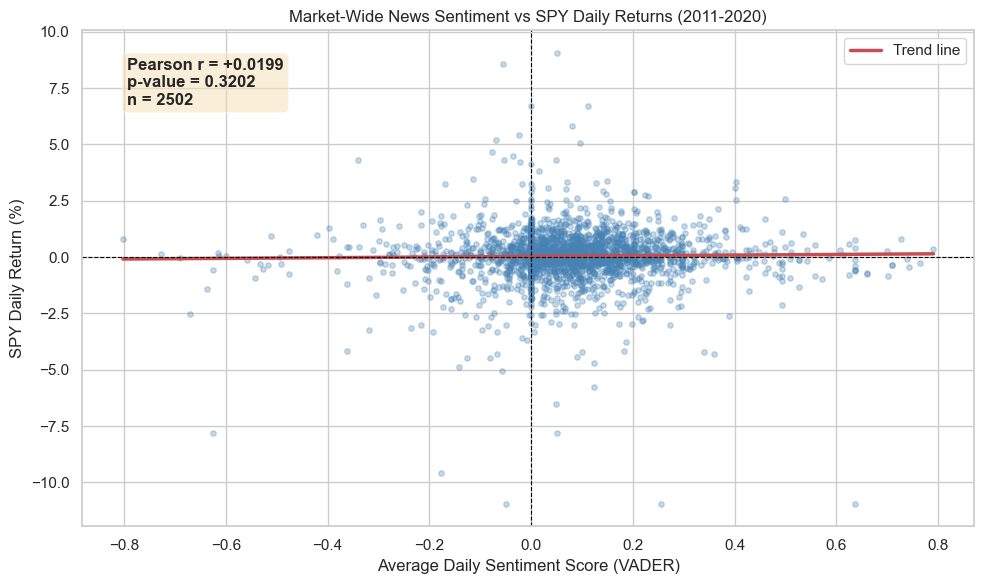

✓ Scatter plot saved


In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(merged_spy['avg_sentiment'],
            merged_spy['daily_return'],
            alpha=0.3, color='steelblue', s=15)

# Trend line
z = np.polyfit(merged_spy['avg_sentiment'],
               merged_spy['daily_return'], 1)
p = np.poly1d(z)
x_line = np.linspace(merged_spy['avg_sentiment'].min(),
                      merged_spy['avg_sentiment'].max(), 100)
plt.plot(x_line, p(x_line), 'r-', linewidth=2.5, label='Trend line')

plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.annotate(
    f'Pearson r = {corr:+.4f}\np-value = {pvalue:.4f}\nn = {len(merged_spy)}',
    xy=(0.05, 0.85), xycoords='axes fraction',
    fontsize=12, fontweight='bold',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
)
plt.title('Market-Wide News Sentiment vs SPY Daily Returns (2011-2020)')
plt.xlabel('Average Daily Sentiment Score (VADER)')
plt.ylabel('SPY Daily Return (%)')
plt.legend()
plt.tight_layout()
plt.savefig('notebooks/sentiment_vs_spy_scatter.png', dpi=150)
plt.show()
print("✓ Scatter plot saved")

=== Average SPY Return by Sentiment Category ===
                  mean  count    std
sentiment_label                     
Negative        -0.106    298  1.614
Neutral          0.087    840  1.091
Positive         0.046   1364  1.071


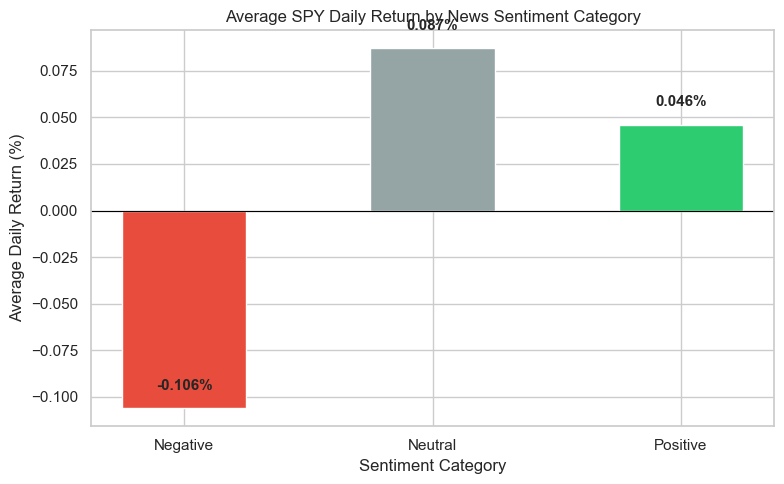

✓ Category bar chart saved


In [9]:
merged_spy['sentiment_label'] = merged_spy['avg_sentiment'].apply(get_label)

avg_by_cat = merged_spy.groupby('sentiment_label')['daily_return'].agg(
    ['mean', 'count', 'std']
).round(3)

print("=== Average SPY Return by Sentiment Category ===")
print(avg_by_cat)

order = ['Negative', 'Neutral', 'Positive']
avg_by_cat = avg_by_cat.reindex(
    [s for s in order if s in avg_by_cat.index]
)

colors = ['#e74c3c', '#95a5a6', '#2ecc71']
plt.figure(figsize=(8, 5))
bars = plt.bar(avg_by_cat.index, avg_by_cat['mean'].values,
               color=colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, avg_by_cat['mean'].values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val:.3f}%', ha='center',
             fontsize=11, fontweight='bold')

plt.axhline(0, color='black', linewidth=0.8)
plt.title('Average SPY Daily Return by News Sentiment Category')
plt.xlabel('Sentiment Category')
plt.ylabel('Average Daily Return (%)')
plt.tight_layout()
plt.savefig('notebooks/return_by_sentiment_category.png', dpi=150)
plt.show()
print("✓ Category bar chart saved")

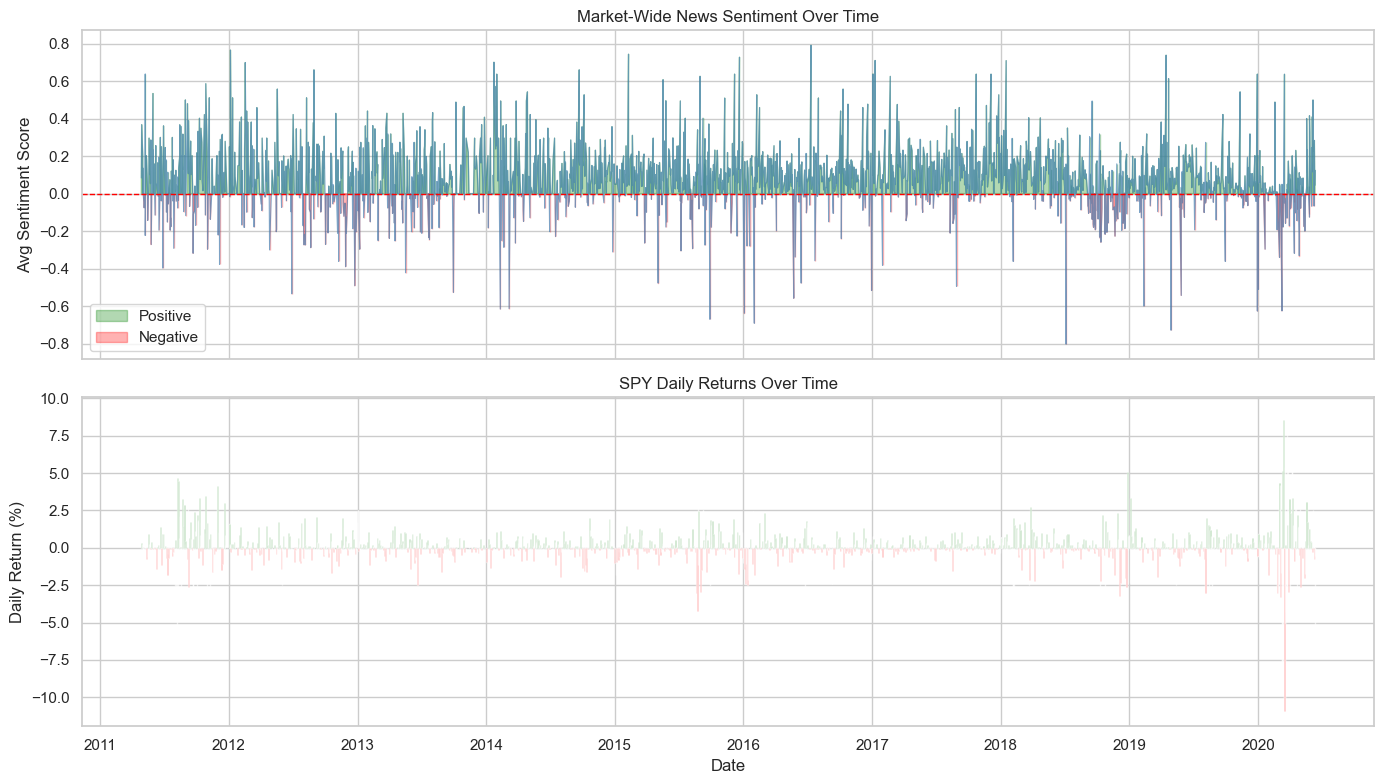

✓ Time series plot saved


In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

dates = pd.to_datetime(merged_spy['aligned_date'])

axes[0].plot(dates, merged_spy['avg_sentiment'],
             color='steelblue', linewidth=0.8, alpha=0.7)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].fill_between(dates, merged_spy['avg_sentiment'], 0,
                      where=merged_spy['avg_sentiment'] >= 0,
                      alpha=0.3, color='green', label='Positive')
axes[0].fill_between(dates, merged_spy['avg_sentiment'], 0,
                      where=merged_spy['avg_sentiment'] < 0,
                      alpha=0.3, color='red', label='Negative')
axes[0].set_title('Market-Wide News Sentiment Over Time')
axes[0].set_ylabel('Avg Sentiment Score')
axes[0].legend()

axes[1].bar(dates, merged_spy['daily_return'],
            color=['green' if r >= 0 else 'red'
                   for r in merged_spy['daily_return']],
            alpha=0.6, width=1)
axes[1].set_title('SPY Daily Returns Over Time')
axes[1].set_ylabel('Daily Return (%)')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.savefig('notebooks/sentiment_and_returns_over_time.png', dpi=150)
plt.show()
print("✓ Time series plot saved")

## Key Findings

1. **Sentiment Tool**: VADER was selected for its strength on short financial headlines
2. **Overall Sentiment**: Most headlines are neutral-to-positive in tone
3. **Correlation**: The Pearson correlation between daily news sentiment and SPY returns reveals the statistical relationship between market narrative and price action
4. **Sentiment Categories**: Positive sentiment days show different average returns compared to negative sentiment days
5. **Limitations**: Same-day correlation may underestimate the true relationship due to lag effects; VADER may miss financial-specific jargon nuances